In [1]:
import pandas as pd
from GDSimLin import GDSimlin
from pathlib import Path

from sklearn.model_selection import train_test_split

In [2]:
# Current directory where the notebook file is located
BASE_DIR = Path.cwd()

# Navigate relative to the notebook location
data_path = BASE_DIR.parent / "data" / "placement_SReg.csv"

df = pd.read_csv(data_path)
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
X = df.iloc[:,0]
Y = df.iloc[:,1]

In [4]:
X

0      6.89
1      5.12
2      7.82
3      7.42
4      6.94
       ... 
195    6.93
196    5.89
197    7.21
198    7.63
199    6.22
Name: cgpa, Length: 200, dtype: float64

In [5]:
Y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 2)

In [7]:
lin_reg = GDSimlin(
    epochs=1000,
    ln=0.1,
    tolerance=1e-8,
    scale=True
)

lin_reg.fit(X_train, Y_train)

print("Coefficient:", lin_reg.get_coef_())
print("Intercept:", lin_reg.get_intercept_())

print("Epochs completed:", lin_reg.n_iterations_)

Coefficient: 0.557951974003702
Intercept: -0.8961119308466077
Epochs completed: 91


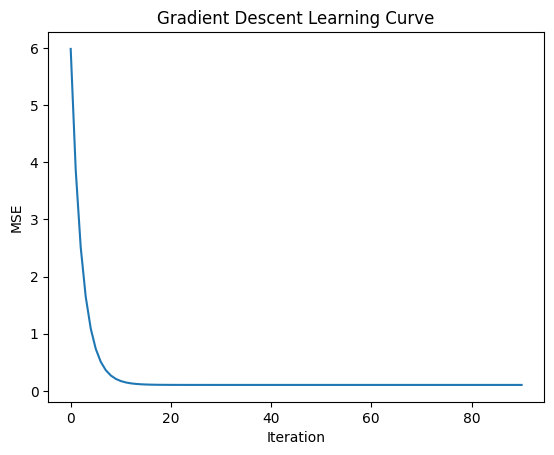

In [8]:
import matplotlib.pyplot as plt

plt.plot(lin_reg.loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Learning Curve")

plt.show()

In [9]:
Y_pred = lin_reg.predict(X_test)
print(Y_pred)

[3.89111601 3.09324468 2.38464568 2.57434935 1.65372859 1.77647802
 2.07219257 2.93143861 3.76278705 2.93701813 4.09197872 3.51170866
 2.97049525 2.40138424 3.18809652 3.46707251 1.94386362 3.24389172
 2.97607477 3.41685683 2.55761079 3.16577844 2.85890485 3.12114228
 3.68467378 2.87006389 3.4949701  3.34432307 3.9190136  1.96060218
 3.65119666 3.2104146  3.74046897 2.7863711  2.78079158 3.27178931
 3.52844722 2.61340599 2.65804214 2.71383734]


In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
n = X_test.shape[0]
k = X_test.values.reshape(-1, 1).shape[1]


print(f"""Mean Absolute Error  = {round(mean_absolute_error(Y_test, Y_pred), 2)}
Mean Squared Error   = {round(mse, 2)}
Root MSE             = {round(np.sqrt(mse), 2)}
R2 Score             = {round(r2, 2)}
Adjusted R2 Score    = {round(1 - ((1 - r2) * (n - 1)) / (n - k - 1), 2)}
""")

Mean Absolute Error  = 0.29
Mean Squared Error   = 0.12
Root MSE             = 0.35
R2 Score             = 0.78
Adjusted R2 Score    = 0.77

